In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



### Load Data

In [265]:
df = pd.read_csv("../data/performance.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [266]:
df.shape

(1044, 33)

In [267]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   str  
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   str  
 16  famsup      1044 non-null   str  
 17  paid        1044 non-null   str  
 18  activities  1044 non-null   str  
 19  nursery     1044 non-null   str  
 20  higher      1044 non-null   str  
 21  in

In [268]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [269]:
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [270]:
df.duplicated().sum()

np.int64(0)

### Visualization

In [271]:
df_copy = df.copy()

In [272]:
df_copy.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [273]:
df_copy["Pass_fail"] = (df_copy["G3"] >= 10).astype(int)

In [274]:
study_map = {0: ">2h", 1: "< 2h", 2: "2-5h", 3: "5-10h", 4: "> 10h"}
df_copy["studytime_label"] = df_copy["studytime"].map(study_map)

order = [">2","< 2h", "2-5h", "5-10h", "> 10h"]

In [275]:
df_copy.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass_fail,studytime_label
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0,2-5h
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0,2-5h
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1,2-5h
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1,5-10h
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1,2-5h


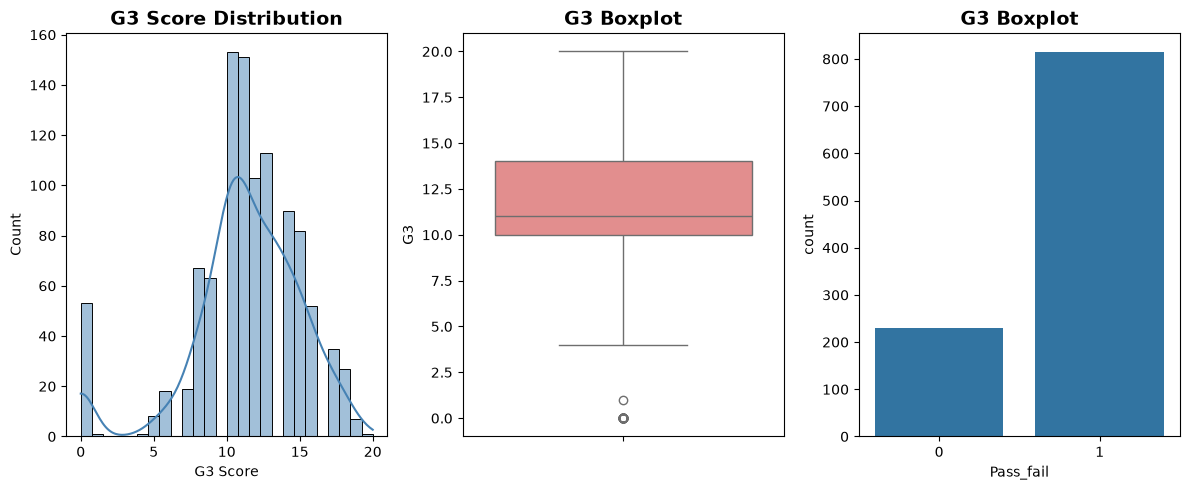

In [276]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes = axes.flatten()
sns.histplot(df_copy["G3"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("G3 Score Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("G3 Score")
sns.boxplot(y=df_copy["G3"], ax=axes[1], color="lightcoral")
axes[1].set_title("G3 Boxplot", fontsize=14, fontweight="bold")
sns.countplot(x=df_copy["Pass_fail"], ax=axes[2])
axes[2].set_title("G3 Boxplot", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

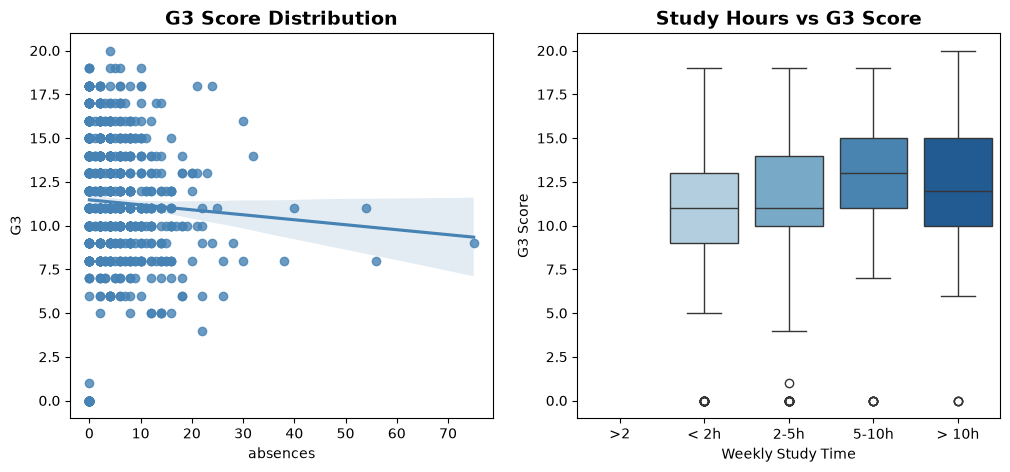

In [277]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(y= "G3", x="absences", data=df_copy, ax=axes[0], color="steelblue")
axes[0].set_title("G3 Score Distribution", fontsize=14, fontweight="bold")


sns.boxplot(data=df_copy, x="studytime_label", y="G3", order=order,
            palette="Blues", ax=axes[1])
axes[1].set_title("Study Hours vs G3 Score", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Weekly Study Time")
axes[1].set_ylabel("G3 Score")
plt.show()

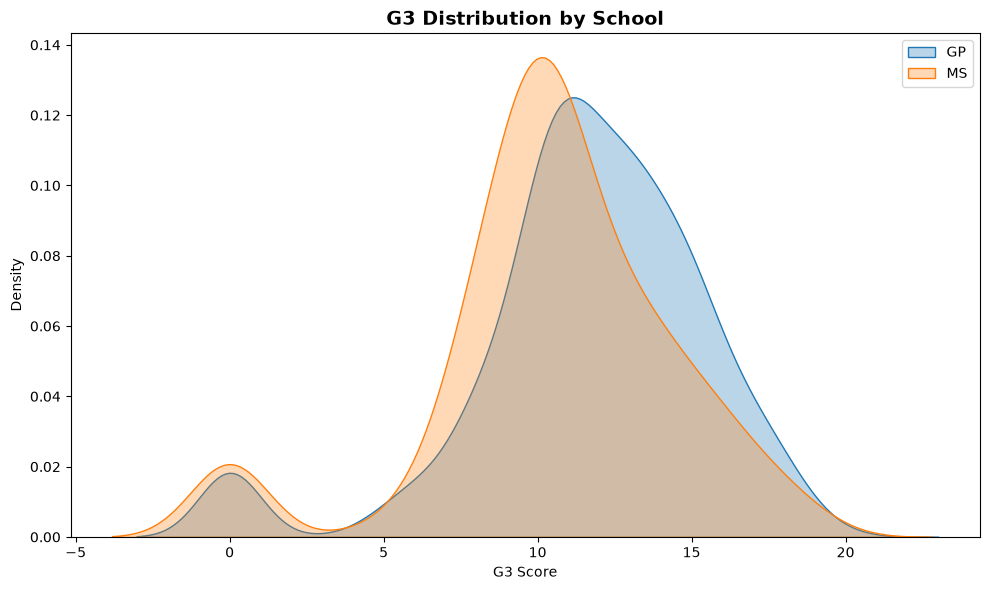

In [278]:
fig, ax = plt.subplots(figsize=(10, 6))
for school, grp in df.groupby("school"):
    sns.kdeplot(grp["G3"], ax=ax, label=school, fill=True, alpha=0.3)
ax.set_title("G3 Distribution by School", fontsize=14, fontweight="bold")
ax.set_xlabel("G3 Score"); ax.legend()
plt.tight_layout()

In [279]:
num_cols = df_copy.select_dtypes(include=["int64", "float64", "number"]).columns

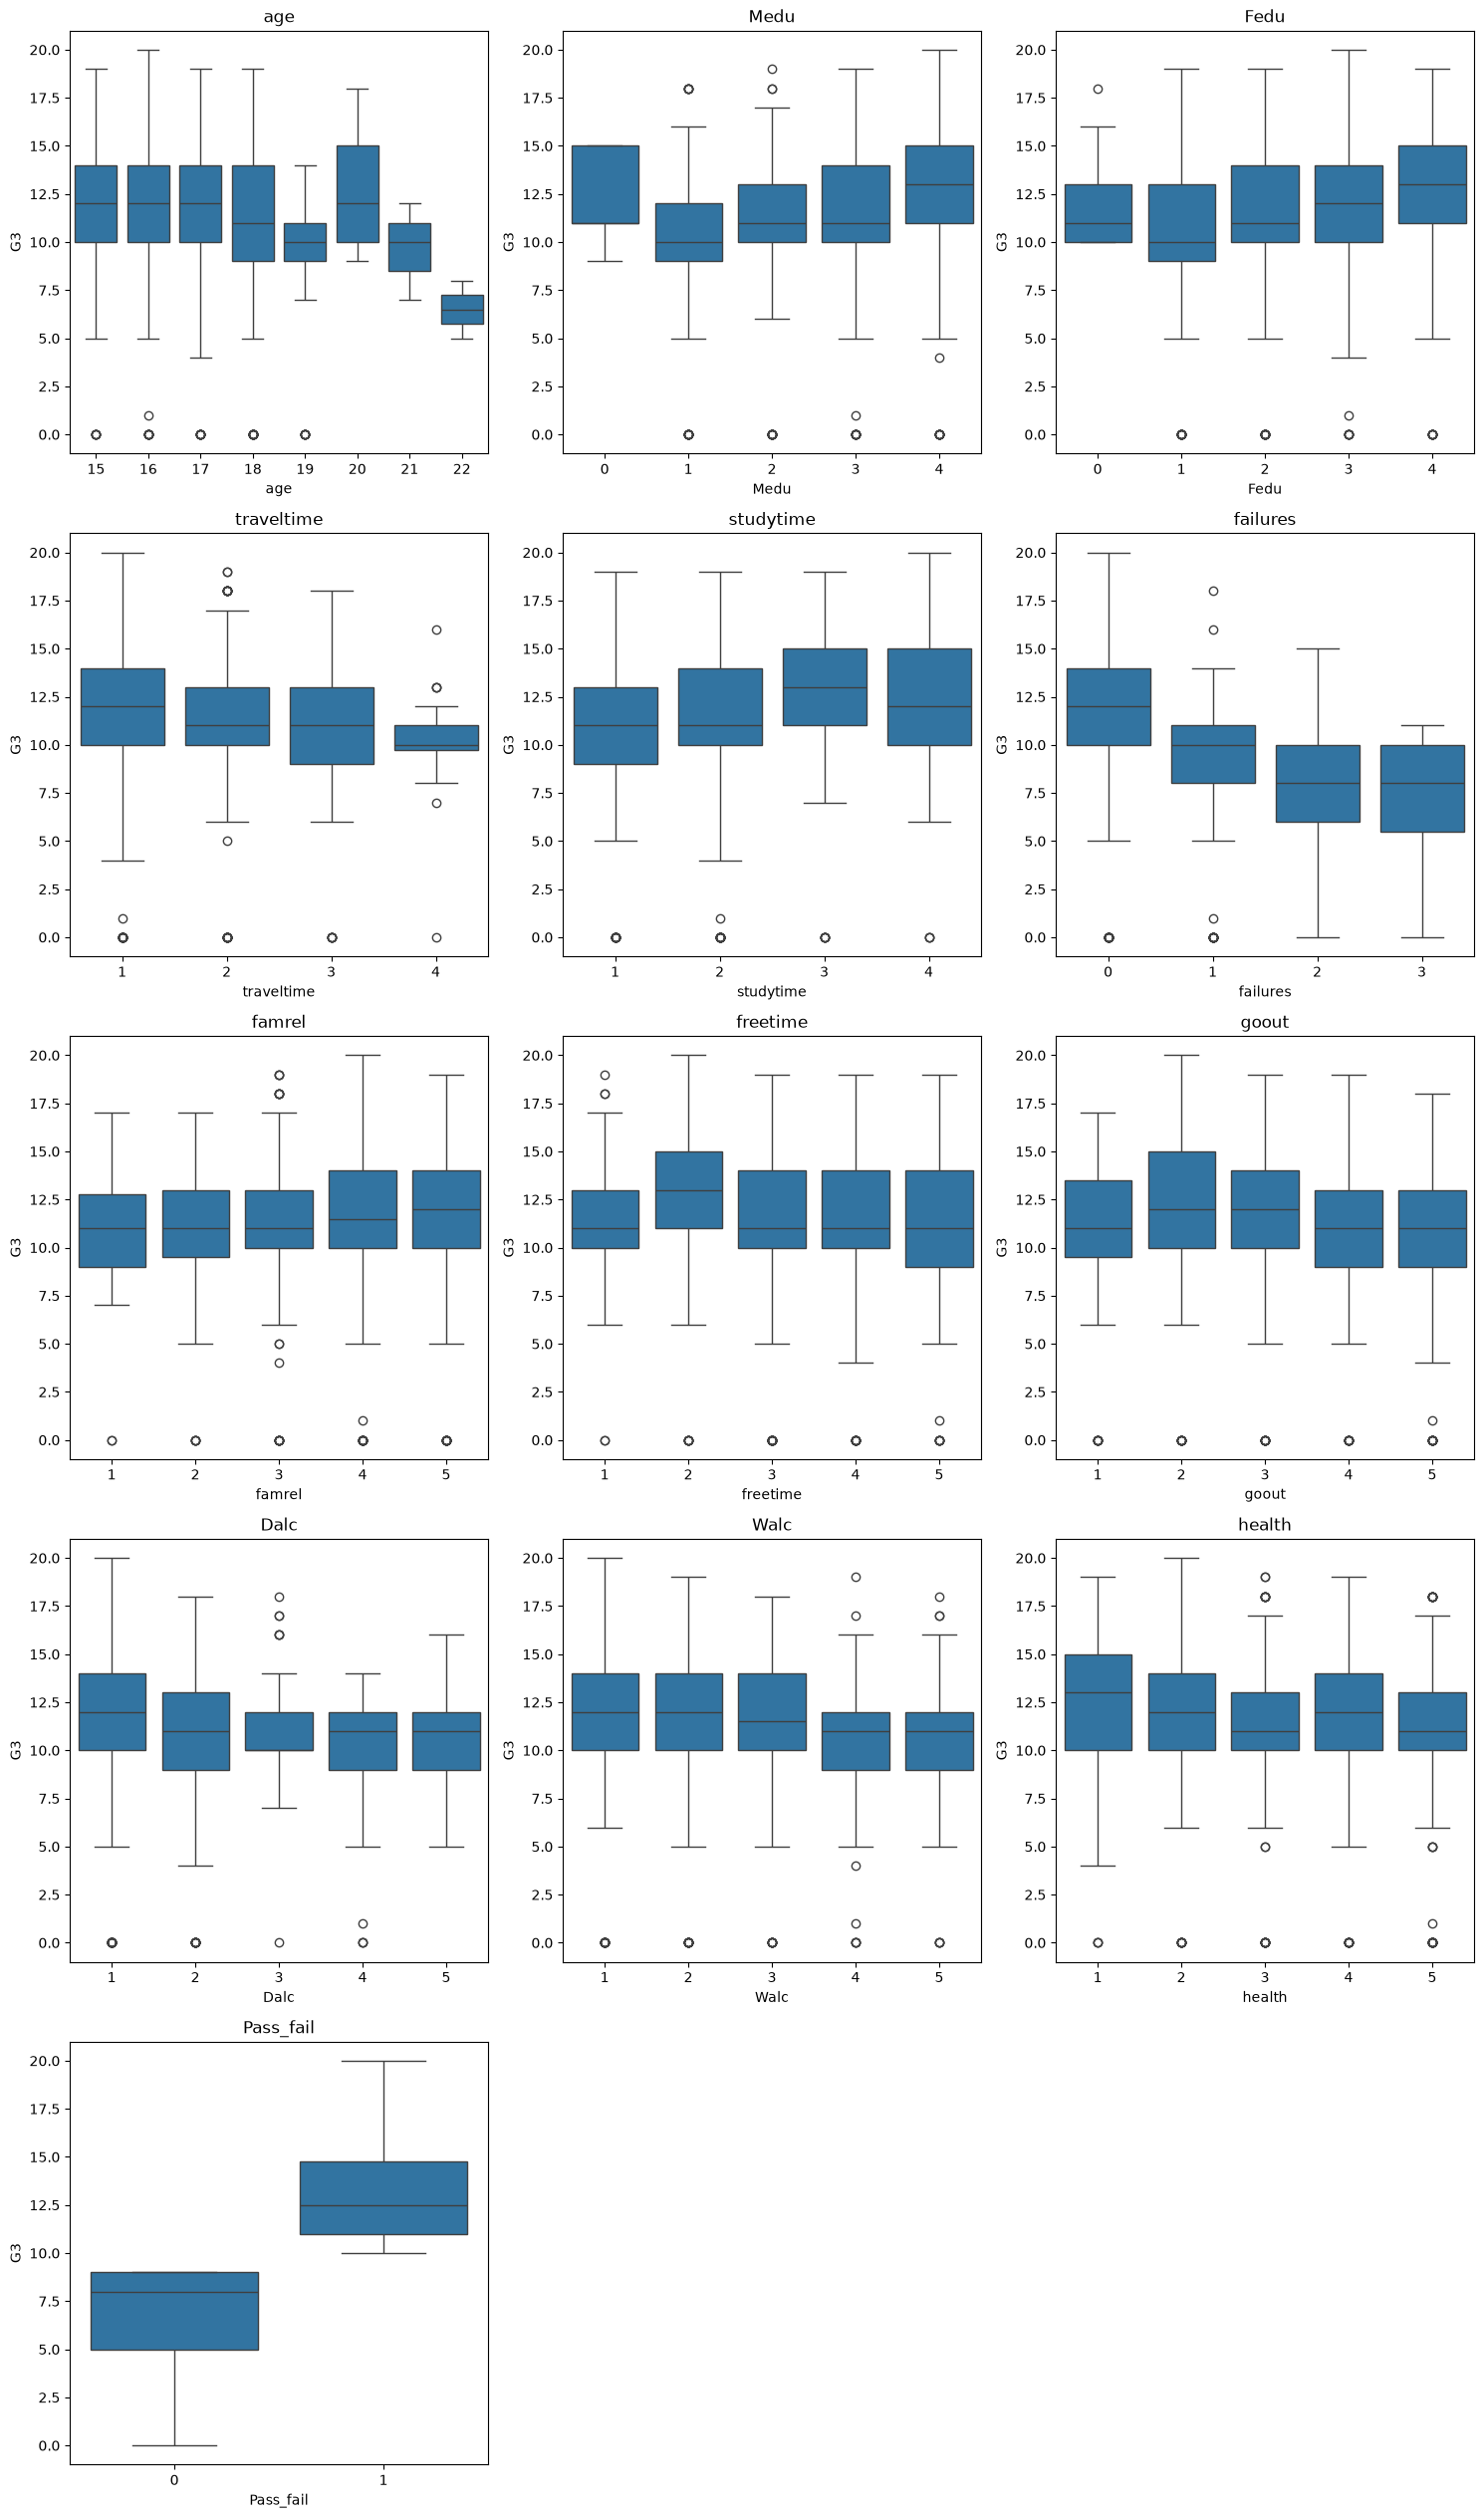

In [280]:
import math

exclude_cols = ["absences","G1","G2","G3"]

fig, axes = plt.subplots(6, 3, figsize=(15, 5 * 6))
axes = axes.flatten()

for i, col in enumerate([col for col in num_cols if col not in exclude_cols]):
    sns.boxplot(x=col, y="G3", data=df_copy, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [281]:
df_copy.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass_fail,studytime_label
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0,2-5h
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0,2-5h
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1,2-5h
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1,5-10h
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1,2-5h


In [282]:
df_copy["parent_edu"] = (df_copy['Medu'] + df_copy['Fedu'])/2

In [283]:
df_copy.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass_fail,studytime_label,parent_edu
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0,2-5h,4.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0,2-5h,1.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1,2-5h,1.0
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1,5-10h,3.0
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1,2-5h,3.0


In [284]:
df_copy["social_score"] = df_copy["freetime"] + df_copy["goout"]

In [285]:
df_copy["alc_consumption"] = ((5 * df_copy["Dalc"] + 2 *df_copy["Walc"]) / 7).round(2)

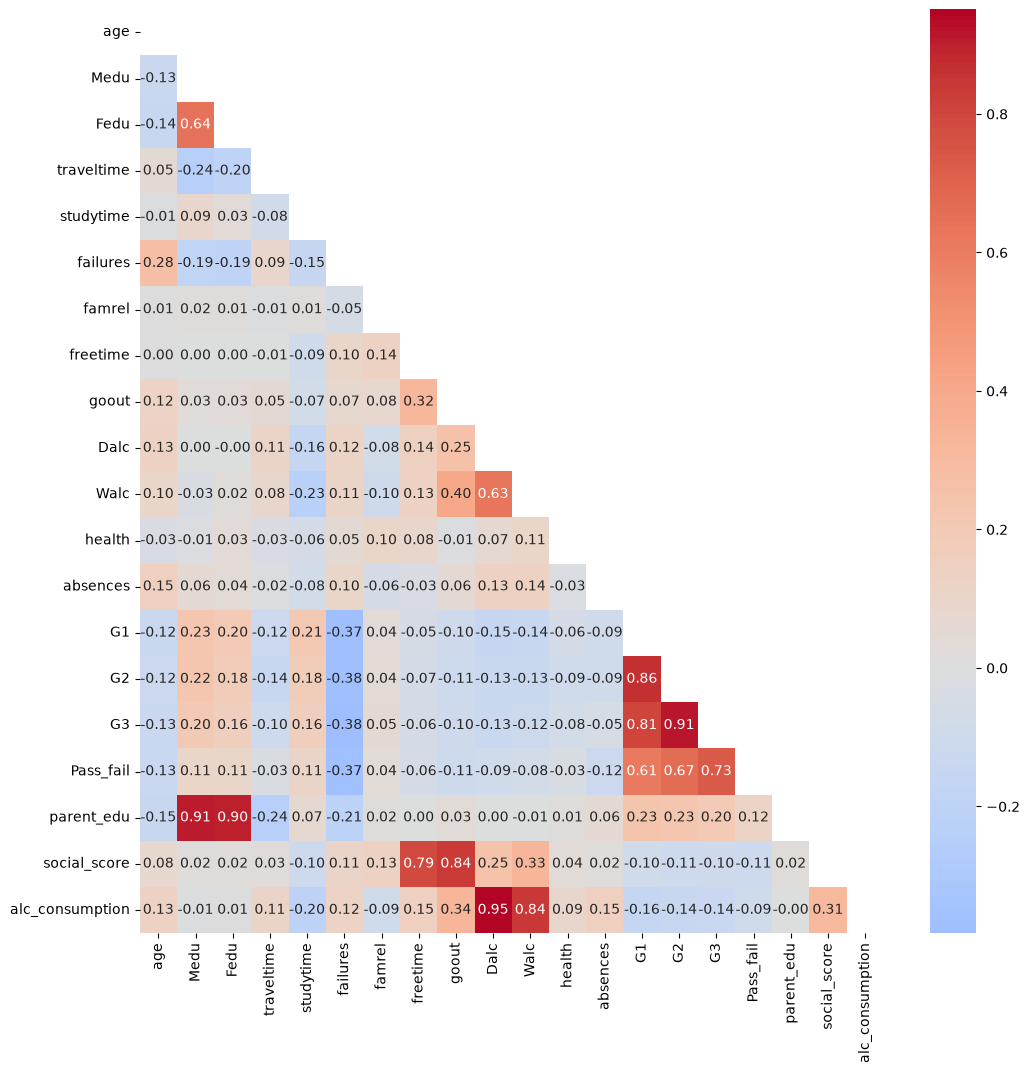

In [286]:
corr = df_copy.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12,12))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.show()

### Encoding (Label Encoder, One hot encoding and Standard Scaler)

In [287]:
df_copy.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass_fail,studytime_label,parent_edu,social_score,alc_consumption
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0,2-5h,4.0,7,1.00
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0,2-5h,1.0,6,1.00
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1,2-5h,1.0,5,2.29
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1,5-10h,3.0,4,1.00
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1,2-5h,3.0,5,1.29


In [288]:
import joblib


label_encoders = {}

le = LabelEncoder()

cols_to_le = [
    "school", "sex", "address",
    "famsize", "Pstatus", "guardian",
    "schoolsup", "famsup", "paid",
    "activities", "nursery", "higher",
    "internet",	"romantic"
    ]

for cols in cols_to_le:
    df_copy[cols] = le.fit_transform(df_copy[cols])
    label_encoders[cols] = le
    
joblib.dump(label_encoders, "../model/label_encoders.pkl")

['../model/label_encoders.pkl']

In [289]:
df_copy.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass_fail,studytime_label,parent_edu,social_score,alc_consumption
0,0,0,18,1,0,0,4,4,at_home,teacher,course,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6,0,2-5h,4.0,7,1.00
1,0,0,17,1,0,1,1,1,at_home,other,course,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6,0,2-5h,1.0,6,1.00
2,0,0,15,1,1,1,1,1,at_home,other,other,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10,1,2-5h,1.0,5,2.29
3,0,0,15,1,0,1,4,2,health,services,home,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15,1,5-10h,3.0,4,1.00
4,0,0,16,1,0,1,3,3,other,other,home,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10,1,2-5h,3.0,5,1.29


In [290]:
# tHIS HAS TO BE DROP BECOZ OF FEATURED ENGINEERING

cols_to_drop = ["Medu", "Fedu", "freetime", "goout", "Dalc", "Walc"]

In [291]:
target = "Pass_fail"
threshold = 0.05

corr = df_copy.corr(numeric_only=True)[target].abs()

drop_cols = corr[corr < threshold].index.tolist()

# Remove the target itself if it appears
if target in drop_cols:
    drop_cols.remove(target)

# Remove target leakage
drop_cols.append("G3")

print("Columns to drop:", drop_cols)



Columns to drop: ['sex', 'famsize', 'Pstatus', 'traveltime', 'schoolsup', 'famsup', 'activities', 'nursery', 'famrel', 'health', 'G3']


In [292]:
all_drop_cols = list(set(drop_cols + cols_to_drop))

In [293]:
all_drop_cols

['Dalc',
 'famsize',
 'Walc',
 'Medu',
 'traveltime',
 'Pstatus',
 'activities',
 'nursery',
 'Fedu',
 'freetime',
 'famsup',
 'famrel',
 'schoolsup',
 'G3',
 'goout',
 'health',
 'sex']

In [294]:
df_copy = df_copy.drop(columns=all_drop_cols)

In [295]:
df_copy.head()

,school,age,address,Mjob,Fjob,reason,guardian,studytime,failures,paid,higher,internet,romantic,absences,G1,G2,Pass_fail,studytime_label,parent_edu,social_score,alc_consumption
0,0,18,1,at_home,teacher,course,1,2,0,0,1,0,0,6,5,6,0,2-5h,4.0,7,1.00
1,0,17,1,at_home,other,course,0,2,0,0,1,1,0,4,5,5,0,2-5h,1.0,6,1.00
2,0,15,1,at_home,other,other,1,2,3,1,1,1,0,10,7,8,1,2-5h,1.0,5,2.29
3,0,15,1,health,services,home,1,3,0,1,1,1,1,2,15,14,1,5-10h,3.0,4,1.00
4,0,16,1,other,other,home,0,2,0,1,1,0,0,4,6,10,1,2-5h,3.0,5,1.29


In [296]:
df_copy["Pass_fail"].value_counts().to_dict()

{1: 814, 0: 230}

In [297]:
X = df_copy.drop("Pass_fail", axis=1)
y = df_copy["Pass_fail"]

In [298]:
ohe_cols = X.select_dtypes(include= ["str"]).columns
num_cols = X.select_dtypes(exclude= ["str"]).columns

In [299]:
process = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [300]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [301]:
X_train.shape, X_test.shape

((835, 20), (209, 20))

In [302]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier, Perceptron
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "LR": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(random_state=42),
    "ET": ExtraTreesClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "Ridge": RidgeClassifier(random_state=42),
    "SGD": SGDClassifier(random_state=42),
    "PA": PassiveAggressiveClassifier(random_state=42),
    "Perceptron": Perceptron(random_state=42),
    "HGB": HistGradientBoostingClassifier(random_state=42),
    "XGB": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LGBM": LGBMClassifier(random_state=42, verbose=-1),
    "MLP": MLPClassifier(random_state=42, max_iter=1000)
}

In [303]:
param_grids = {

    "LR": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "DT": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "RF": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2"]
    },

    "ET": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2"]
    },

    "GB": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__subsample": [0.8, 1.0]
    },

    "AdaBoost": {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.01, 0.1, 1]
    },

    "Bagging": {
        "model__n_estimators": [10, 25, 50, 100],
        "model__max_samples": [0.5, 0.8, 1.0],
        "model__max_features": [0.5, 0.8, 1.0]
    },

    "Ridge": {
        "model__alpha": [0.1, 1, 10, 100]
    },

    "SGD": {
        "model__loss": ["hinge", "log_loss"],
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__penalty": ["l2", "l1"]
    },

    "PA": {
        "model__C": [0.1, 1, 10],
        "model__loss": ["hinge", "squared_hinge"]
    },

    "Perceptron": {
        "model__penalty": [None, "l2", "l1"],
        "model__alpha": [0.0001, 0.001, 0.01]
    },

    "HGB": {
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [None, 5, 10],
        "model__max_iter": [100, 200, 300],
        "model__min_samples_leaf": [20, 50]
    },

    "XGB": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    },

    "LGBM": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [-1, 5, 10],
        "model__num_leaves": [31, 50, 100]
    },

    "MLP": {
        "model__hidden_layer_sizes": [(100,), (100, 50), (200,)],
        "model__activation": ["relu", "tanh"],
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.001, 0.01]
    }

}

In [304]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

from imblearn.pipeline import Pipeline as IMBPipeline
from imblearn.over_sampling import SMOTE

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
trained_models = {}

for name, model in models.items():

    pipeline = IMBPipeline(
        steps=[
            ('process', process),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ]
    )

    # Cross Validation
    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=skf,
        scoring='f1'
    )

    # Train on complete training data
    pipeline.fit(X_train, y_train)

    # Save trained model
    trained_models[name] = pipeline

    # Predictions on test data
    y_pred = pipeline.predict(X_test)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Store results
    results.append({
        "Model": name,
        "CV F1 Mean": round(cv_scores.mean(), 4),
        "CV F1 Std": round(cv_scores.std(), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall (Sensitivity)": round(recall_score(y_test, y_pred), 4),
        "Specificity": round(tn / (tn + fp), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,CV F1 Mean,CV F1 Std,Accuracy,Precision,Recall (Sensitivity),Specificity,F1 Score,TP,TN,FP,FN
0,RF,0.9455,0.0065,0.8947,0.9325,0.9325,0.7609,0.9325,152,35,11,11
1,Bagging,0.9379,0.0126,0.8947,0.9379,0.9264,0.7826,0.9321,151,36,10,12
2,GB,0.9449,0.0091,0.8947,0.9434,0.9202,0.8043,0.9317,150,37,9,13
3,ET,0.9353,0.0094,0.8900,0.9167,0.9448,0.6957,0.9305,154,32,14,9
4,DT,0.9283,0.0123,0.8900,0.9268,0.9325,0.7391,0.9297,152,34,12,11
5,Perceptron,0.9108,0.0139,0.8852,0.9264,0.9264,0.7391,0.9264,151,34,12,12
6,MLP,0.9375,0.0046,0.8852,0.9264,0.9264,0.7391,0.9264,151,34,12,12
7,LGBM,0.9421,0.0097,0.8852,0.9371,0.9141,0.7826,0.9255,149,36,10,14
8,AdaBoost,0.9386,0.0092,0.8852,0.9542,0.8957,0.8478,0.9241,146,39,7,17
9,HGB,0.9427,0.0120,0.8804,0.9259,0.9202,0.7391,0.9231,150,34,12,13


In [305]:
from sklearn.model_selection import GridSearchCV

best_models = {}
grid_results = []

for name, model in models.items():

    print(f"Tuning {name}...")

    pipeline = IMBPipeline([
        ("process", process),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring="f1",
        cv=skf,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    grid_results.append({
        "Model": name,
        "Best F1": grid.best_score_,
        "Best Params": grid.best_params_
    })



Tuning LR...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Tuning SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Tuning DT...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Tuning RF...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Tuning ET...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Tuning GB...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Tuning AdaBoost...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Tuning Bagging...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tuning Ridge...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Tuning SGD...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Tuning PA...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuning Perceptron...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Tuning HGB...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Tuning XGB

In [306]:
grid_results = (
    pd.DataFrame(grid_results)
    .sort_values("Best F1", ascending=False)
    .reset_index(drop=True)
)

grid_results

,Model,Best F1,Best Params
0,RF,0.956019,"{'model__max_depth': None, 'model__max_feature..."
1,XGB,0.954014,"{'model__colsample_bytree': 0.8, 'model__learn..."
2,Bagging,0.953045,"{'model__max_features': 0.5, 'model__max_sampl..."
3,GB,0.951625,"{'model__learning_rate': 0.05, 'model__max_dep..."
4,LGBM,0.950250,"{'model__learning_rate': 0.1, 'model__max_dept..."
5,HGB,0.950033,"{'model__learning_rate': 0.05, 'model__max_dep..."
6,AdaBoost,0.947656,"{'model__learning_rate': 0.1, 'model__n_estima..."
7,MLP,0.944286,"{'model__activation': 'relu', 'model__alpha': ..."
8,SGD,0.942747,"{'model__alpha': 0.01, 'model__loss': 'hinge',..."
9,DT,0.939960,"{'model__criterion': 'entropy', 'model__max_de..."


In [308]:
import joblib

# Get the best Random Forest model
best_model = best_models["RF"]

# Save the complete pipeline (preprocessing + SMOTE + model)
joblib.dump(best_model, "../model/best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [310]:
import joblib

model = joblib.load("../model/best_model.pkl")

In [311]:
print(best_model)


Pipeline(steps=[('process',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Mjob', 'Fjob', 'reason', 'studytime_label'], dtype='str')),
                                                 ('num', StandardScaler(),
                                                  Index(['school', 'age', 'address', 'guardian', 'studytime', 'failures', 'paid',
       'higher', 'internet', 'romantic', 'absences', 'G1', 'G2', 'parent_edu',
       'social_score', 'alc_consumption'],
      dtype='str'))])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(min_samples_split=5, n_estimators=200,
                                        random_state=42))])
